In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
class Value:
    
    def __init__(self,data ,_children = (),_op = '',label = ""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label =label
        self.grad = 0.0
        self._backward = lambda : None
        
    def __repr__(self):
        return f"Value(data={self.data})"
        
    def __add__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data + other.data,(self,other),"+")
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __pow__(self,other):
        assert isinstance(other,(int,float)),"only supporting int/float for now"
        out = Value(self.data ** other , (self,),f"**{other}")

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward

        return out

    def __rmul__(self,other):
        return self * other 
        
    def __mul__(self,other):
        other = other if isinstance(other,Value) else Value(other)
        out = Value(self.data * other.data , (self,other),"*")
        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __truediv__(self,other):
        return self * (other ** -1)

    def __neg__(self):
        return self * -1

    def __sub__(self,other):
        return self + (-other)
    def tanh(self):
        n = self.data
        t = (math.exp(2*n)-1)/(math.exp(2*n) + 1)
        out = Value(t,(self,),'tanh')
        def _backward():
            self.grad += (1 - out.data ** 2) * out.grad
        out._backward = _backward
    
        return out
    def exp(self):
        x = self.data
        out = Value(math.exp(x) , (self,),'exp')

        def _backward():
            self.grad += out.data * out.grad
        out._backward = _backward

        return out
        
    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
        build_topo(self)
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()

In [3]:
a = Value(2)
b = a + 10
b - a - 5 - 2

Value(data=3)

In [4]:
from graphviz import Digraph

def trace(root):
    nodes,edges = set(),set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child,v))
                build(child)
    build(root)
    return nodes,edges

def draw_dot(root):
    dot = Digraph(format = "svg" ,graph_attr =  {'rankdir' : 'LR'})

    nodes,edges = trace(root)
    for n in nodes:

        uid = str(id(n))
        dot.node(name = uid , label = "{%s | data %.4f | grad %.4f}" % (n.label,n.data,n.grad ), shape = 'record')
        if n._op:
            dot.node(name = uid + n._op, label = n._op)
            dot.edge(uid + n._op , uid)

    for n1,n2 in edges:
        dot.edge(str(id(n1)),str(id(n2)) + n2._op)

    return dot

In [5]:
x1 = Value(2.0, label = 'x1')
x2 = Value(0.0,label = 'x2')

w1 = Value(-3.0 , label = 'w1')
w2 = Value(1.0 , label = 'w2')

b = Value(6.881373587019 , label ='b')

x1w1 = x1 * w1
x2w2 = x2 * w2
x1w1.label = 'x1*w1'
x2w2.label = 'x2*w2'

x1w1x2w2 = x1w1 + x2w2 ; x1w1x2w2.label = 'x1w1 + x2w2'
n = x1w1x2w2 + b;n.label = 'n'
e =(2 * n).exp()
o = (e-1)/(e + 1)
o.label = "o"

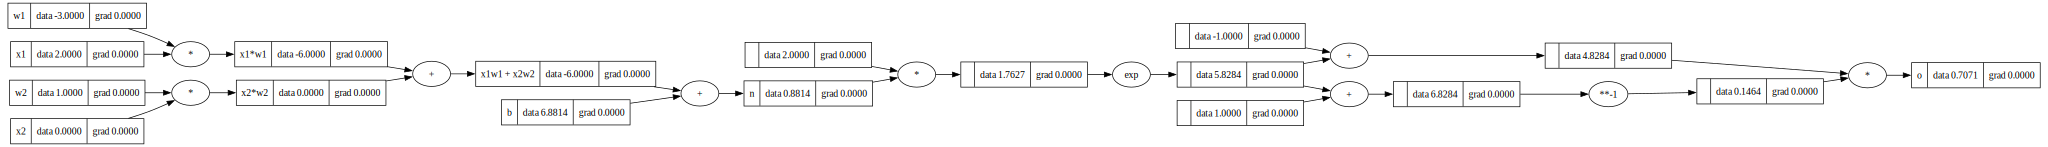

In [6]:
draw_dot(o)

In [7]:
o.backward()


In [8]:
import random
class Neuron:
    def __init__(self,nin):
        self.w = [Value(random.uniform(-1,1)) for _ in range (nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self,x):
        act = sum((wi * xi for wi ,xi in zip(self.w,x)), self.b)
        out = act.tanh()
        return out
        
    def parameters(self):
        return self.w + [self.b]
        
class Layer:
    def __init__(self,nin,nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self,x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs) == 1 else outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            ps = neuron.parameters()
            params.extend(ps)
        return params

class MLP:
    def __init__(self,nin,nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i] ,sz[i+1]) for i in range (len(nouts))]

    def __call__(self,x):
        for layer in self.layers:
            x = layer(x)
        return x

    def parameters(self):
        params = []
        for layer in self.layers:
            params.extend(layer.parameters())
        return params
        
    def zero_grad(self):
        for p in self.parameters():
            p.grad = 0.0
        

In [38]:
x = [2.0,3.0,-1.0]
n = MLP(3,[4,4,1])
n(x)

Value(data=0.5334180836755268)

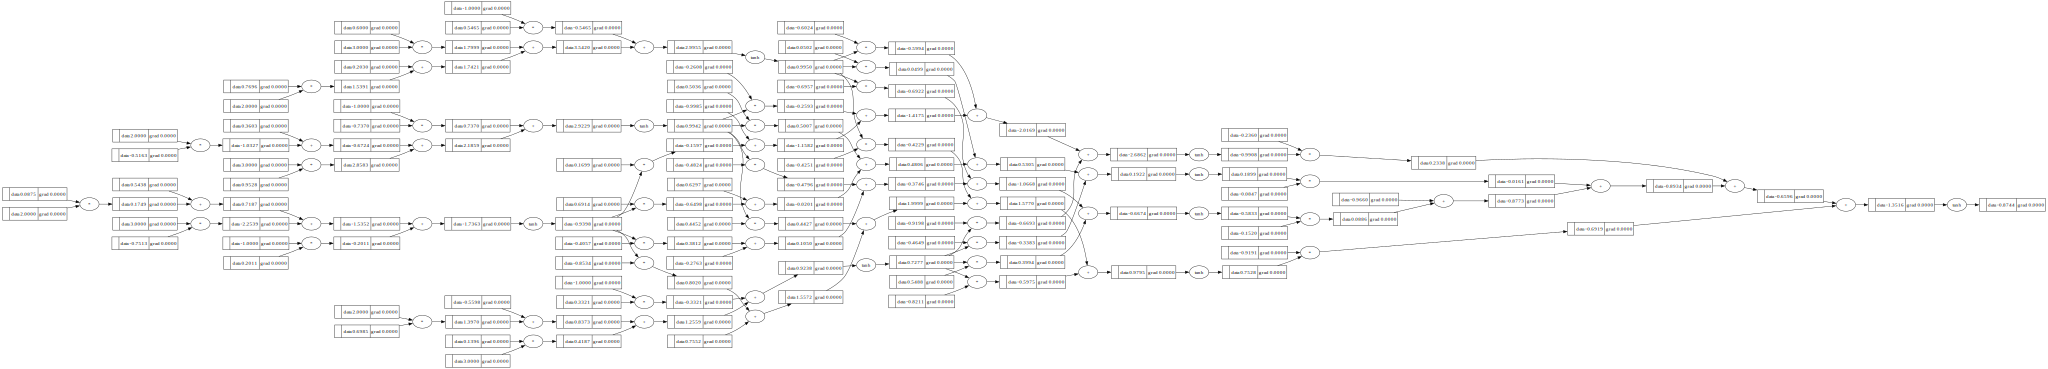

In [10]:
draw_dot(n(x))

In [19]:
xs = [
    [8.0,3.0,-3.0],
    [5.0,-1.5,0.5],
    [0.9,1.0,7.0],
    [1.0,2.0,-1.0],
]
ys = [1.0,0.5,-0.9,-1]


In [46]:
ypred = [n(x) for x in xs]
loss = sum(((yout - ygt)**2 for ygt , yout in zip(ys,ypred)),Value(0.0))
loss


Value(data=4.563923910734877)

In [44]:
\


In [47]:
for k in range (200):
    ypred = [n(x) for x in xs]
    loss = sum(((yout - ygt)**2 for ygt , yout in zip(ys,ypred)),Value(0.0))

    for p in n.parameters():
        p.grad = 0.0
    loss.backward()

    for p in n.parameters():
        p.data += -0.05 * p.grad
    print(k,loss.data)

0 4.563923910734877
1 2.6532636596306047
2 1.4321470141582684
3 0.9159415474874479
4 0.6400402759692653
5 0.4733992690151475
6 0.36951584907119367
7 0.3023860042382921
8 0.2570801775082904
9 0.2251329080300821
10 0.20165016971580885
11 0.18370324616840078
12 0.16947176378383322
13 0.1577830797560523
14 0.14785863875817393
15 0.1391704421820878
16 0.13135763698122765
17 0.12417641027830875
18 0.11746802954519801
19 0.11113620227671185
20 0.10512899157403818
21 0.09942345674384395
22 0.0940130002868324
23 0.0888979239409868
24 0.08407929573100417
25 0.0795556448592068
26 0.07532170367569056
27 0.07136842500268722
28 0.0676836608940317
29 0.06425307939308861
30 0.06106106622463072
31 0.058091487495056125
32 0.05532827365979644
33 0.05275583158563449
34 0.05035931209490964
35 0.04812476563389857
36 0.046039216350565494
37 0.044090679576019705
38 0.042268141947594755
39 0.040561518289834765
40 0.03896159523782631
41 0.037459968442886515
42 0.03604897789937396
43 0.03472164429490285
44 0.033

In [48]:

ypred

[Value(data=0.9488840657148784),
 Value(data=0.5010781857901155),
 Value(data=-0.9021027604882254),
 Value(data=-0.9652833356170005)]

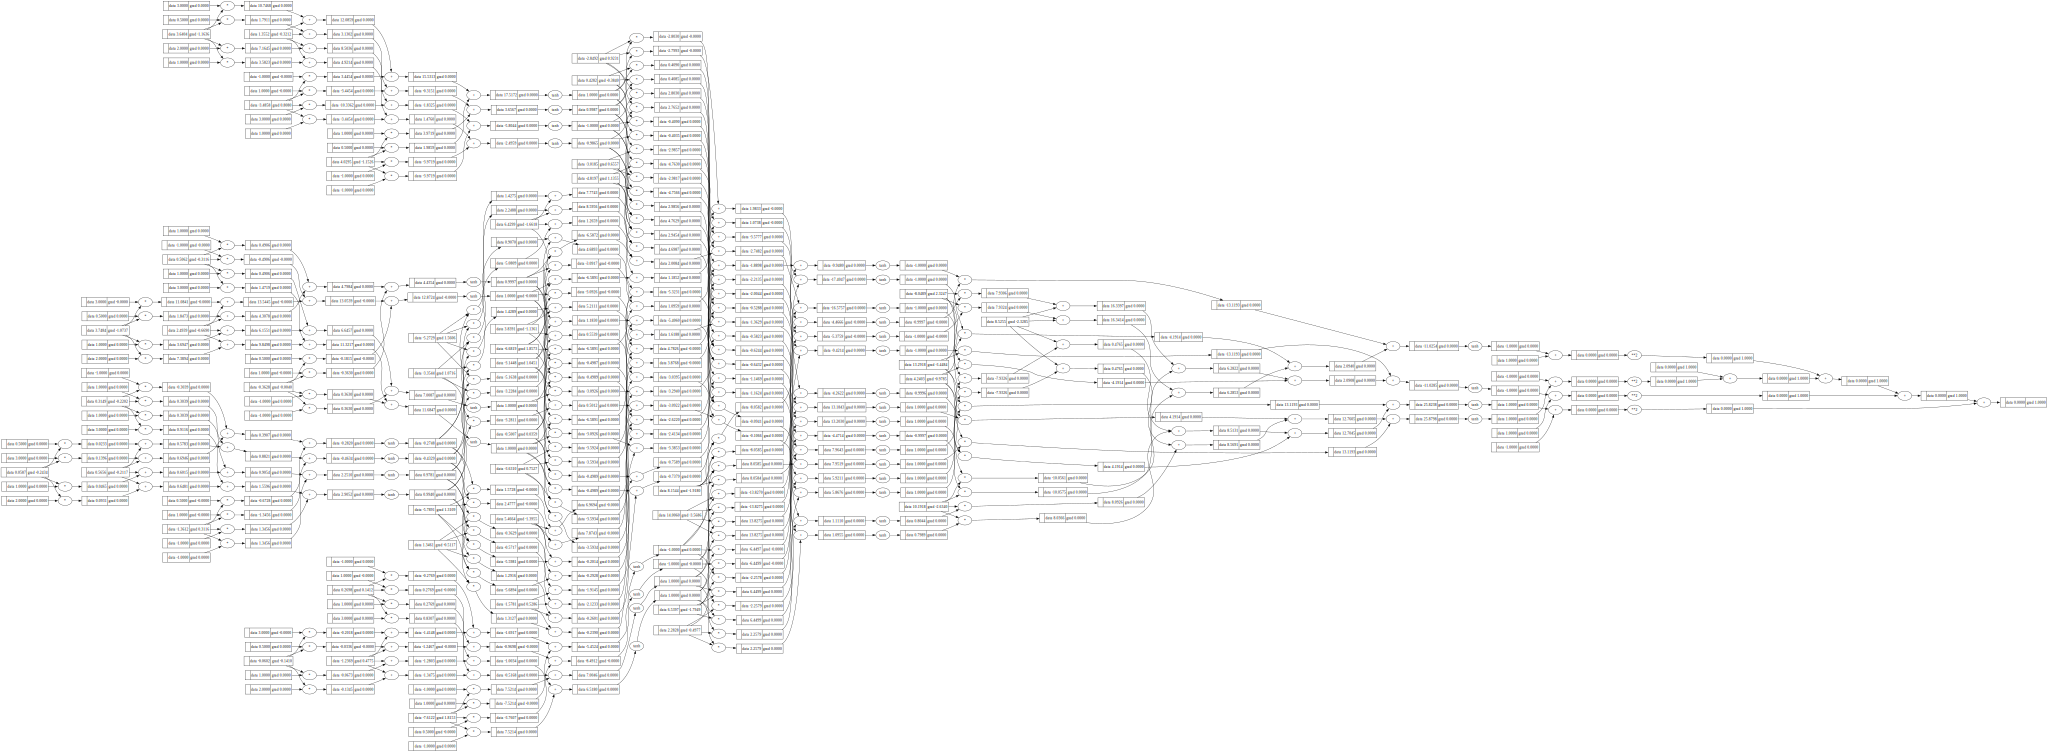

In [169]:
draw_dot(loss)